# 05 — Logistic regression: single-vehicle time series (heavy_user)

The first real model, and deliberately the simplest one — per the coach's suggestion and standard
practice (fit the simplest model before reaching for anything more complex). Trained only on the
45 features `03_feature_selection.ipynb` actually selected, not the full 54 candidates.

**Why logistic regression first, stated plainly:** it's fast, its coefficients are directly
interpretable (does a higher `Battery_Temp` push the fault probability up or down — does that match
physical intuition), and it gives a real number the tree models in notebook 06 have to beat to
justify their added complexity, same principle as the baselines in notebook 04.


In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load — selected features only, same split as every prior notebook

In [2]:
df = pd.read_csv("../data/processed/heavy_user_features.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df["Fault_Within_6h"] = df["Fault_Within_6h"].astype(bool)

with open("../data/processed/selected_feature_cols.json") as f:
    SELECTED_FEATURE_COLS = json.load(f)

print(f"Training on {len(SELECTED_FEATURE_COLS)} selected features (notebook 03's output, not all 54 candidates).")

TEST_FRAC = 0.2
cutoff = int(len(df) * (1 - TEST_FRAC))
train_df = df.iloc[:cutoff].copy()
test_df = df.iloc[cutoff:].copy()

X_train, y_train = train_df[SELECTED_FEATURE_COLS], train_df["Fault_Within_6h"]
X_test, y_test = test_df[SELECTED_FEATURE_COLS], test_df["Fault_Within_6h"]

print(f"Train: {len(X_train):,} rows, Test: {len(X_test):,} rows")


Training on 45 selected features (notebook 03's output, not all 54 candidates).
Train: 35,016 rows, Test: 8,755 rows


## 2. Fit — scaled inputs, balanced class weights

Scaling matters here specifically because logistic regression's coefficients (and the regularization
it's fit with) are sensitive to feature magnitude — `Motor_RPM` and `SOC` live on very different
scales, and without scaling the raw magnitude of a feature would distort how much weight it gets,
independent of its actual relationship with the target.


In [3]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)),
])
logreg.fit(X_train, y_train)
print("Fitted.")


Fitted.


## 3. Evaluate on the held-out test set

              precision    recall  f1-score   support

       False   0.937404  0.658325  0.773460      7393
        True   0.291047  0.761380  0.421117      1362

    accuracy                       0.674358      8755
   macro avg   0.614225  0.709853  0.597289      8755
weighted avg   0.836851  0.674358  0.718647      8755



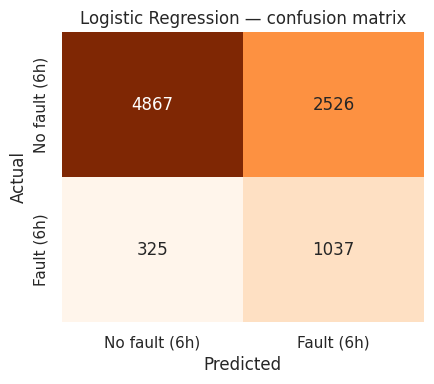

In [4]:
pred = logreg.predict(X_test)

print(classification_report(y_test, pred, labels=[False, True], digits=6, zero_division=0))

cm = confusion_matrix(y_test, pred, labels=[False, True])
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax, cbar=False,
            xticklabels=["No fault (6h)", "Fault (6h)"], yticklabels=["No fault (6h)", "Fault (6h)"])
ax.set_title("Logistic Regression — confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


## 4. Coefficient sanity check — do the signs make physical sense?

This is the part a tree model can't easily give you: a direct, signed, per-feature estimate of
direction. Worth checking a handful of these against physical intuition before trusting the model —
if `SOH` (state of health) has a positive coefficient (higher health -> higher fault probability),
that's a red flag worth investigating, not something to gloss over.


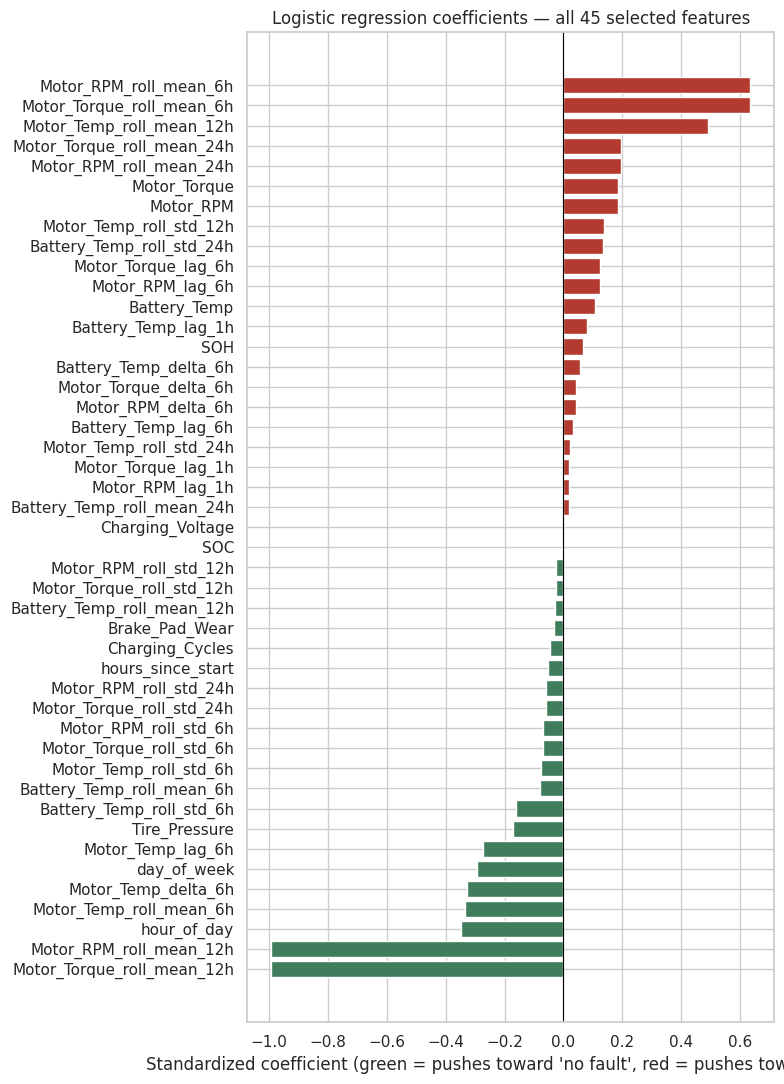

In [5]:
coefs = pd.Series(logreg.named_steps["clf"].coef_[0], index=SELECTED_FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 11))
colors = ["#B23A2E" if c > 0 else "#3F7D5C" for c in coefs.values]
ax.barh(coefs.index, coefs.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized coefficient (green = pushes toward 'no fault', red = pushes toward 'fault')")
ax.set_title("Logistic regression coefficients — all 45 selected features")
plt.tight_layout()
plt.show()


In [6]:
print("Sign check on a few physically-interpretable features:")
for feat in ["SOH", "Charging_Cycles", "Battery_Temp", "Brake_Pad_Wear", "SOC"]:
    if feat in coefs.index:
        direction = "higher value -> HIGHER fault probability" if coefs[feat] > 0 else "higher value -> LOWER fault probability"
        print(f"  {feat}: coef={coefs[feat]:.6f} ({direction})")


Sign check on a few physically-interpretable features:
  SOH: coef=0.066654 (higher value -> HIGHER fault probability)
  Charging_Cycles: coef=-0.043885 (higher value -> LOWER fault probability)
  Battery_Temp: coef=0.106878 (higher value -> HIGHER fault probability)
  Brake_Pad_Wear: coef=-0.031757 (higher value -> LOWER fault probability)
  SOC: coef=-0.004462 (higher value -> LOWER fault probability)


**Reading this, in plain terms:** `SOH` (state of health) dropping should physically mean a
higher chance of a fault soon — so we'd expect a *negative* coefficient (higher SOH -> lower fault
odds). `Charging_Cycles` and `Brake_Pad_Wear` accumulating over time (more wear) should push *toward*
a fault, so a positive coefficient there makes sense. If the printed signs above match this
reasoning, that's a genuine, independent sanity check that the model learned something physically
coherent — not just numerically convenient. If any sign looks backwards, that's worth investigating
before trusting this model's output, not something to quietly ignore.


## 5. Add to the running scoreboard

**Metric update (per coach feedback):** fault (`True`) is the positive class from here on;
precision/recall/F1 on that class are the headline numbers, macro F1 kept only as a secondary
reference — a DummyClassifier check confirmed macro F1 alone can look deceptively OK (~0.48) even
for a model that never predicts a fault.


In [7]:
with open("../models/baseline_results.json") as f:
    results = json.load(f)

results["Logistic Regression (balanced, scaled, 45 features)"] = {
    "recall_fault": recall_score(y_test, pred, pos_label=True, zero_division=0),
    "precision_fault": precision_score(y_test, pred, pos_label=True, zero_division=0),
    "F1_fault": f1_score(y_test, pred, pos_label=True, zero_division=0),
    "macro_F1_secondary": f1_score(y_test, pred, average="macro", zero_division=0),
}

with open("../models/baseline_results.json", "w") as f:
    json.dump(results, f, indent=2)

scoreboard = pd.DataFrame(results).T.round(6)
scoreboard


,recall_fault,precision_fault,F1_fault,macro_F1_secondary
Majority class,0.000000,0.000000,0.000000,0.457828
Naive persistence (6h lookback),0.166667,0.166667,0.166667,0.506572
"Logistic Regression (balanced, scaled, 45 features)",0.761380,0.291047,0.421117,0.597289


**Reading the scoreboard so far:** compare this row directly against notebook 04's two
baselines — same test rows, same metrics, side by side. If logistic regression doesn't clearly beat
naive persistence, that's an honest finding to report, not something to bury.


In [8]:
import os
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(logreg, "../models/logistic_regression.joblib")
print("Saved ../models/logistic_regression.joblib")


Saved ../models/logistic_regression.joblib


## 6. What this notebook establishes, going into notebook 06

1. A real, interpretable first model, with its coefficients checked against physical intuition —
   not just a number, a sanity-checked number.
2. A running scoreboard now has three rows (majority class, naive persistence, logistic regression) —
   notebook 06's Random Forest and XGBoost results get added to the same table, same test rows.
3. If logistic regression already captures most of the achievable signal, that's useful context for
   how much the tree models are actually adding, going in with a number to compare against rather
   than an assumption that "the fancier model will obviously be better."
